In [22]:
import pandas as pd 
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

In [23]:
('''Q1. Missing Data Identification
Scenario: 
The hospital suspects incomplete patient records.
Task:

Identify missing values in each column

Calculate percentage of missing data  ''')


'Q1. Missing Data Identification\nScenario:\u2028\nThe hospital suspects incomplete patient records.\nTask:\n\nIdentify missing values in each column\n\nCalculate percentage of missing data\u2028 '

In [24]:
# Identify missing values in each column
missing_count = df.isnull().sum()

# Calculate the percentage of missing data for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine the results into a clean summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})

print("Missing Data Summary:")
print(missing_summary)

Missing Data Summary:
                    Missing Values  Percentage (%)
Patient_ID                       0        0.000000
Age                            600       11.764706
Gender                           0        0.000000
City                             0        0.000000
Diagnosis                        0        0.000000
Hospital_Visits                  0        0.000000
Treatment_Cost                 593       11.627451
Insurance_Coverage               0        0.000000
Admission_Date                   0        0.000000


In [25]:
('''Q2. Handling Missing Age

Scenario: 
Age is critical for medical analysis, but some values are missing.

Task:

Replace missing Age values with an appropriate method

Justify your choice (mean/median) ''')


'Q2. Handling Missing Age\n\nScenario:\u2028\nAge is critical for medical analysis, but some values are missing.\n\nTask:\n\nReplace missing Age values with an appropriate method\n\nJustify your choice (mean/median)\u2028'

In [26]:
# Choice & Justification: The 'median' is chosen because age can sometimes contain 
# extreme values or skewed tracking. The median prevents potential outliers from 
# shifting the imputed center, and it ensures we work with solid, whole integers.
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

print(f"Missing Age values successfully imputed using the median age: {age_median}")

Missing Age values successfully imputed using the median age: 50.0


In [27]:
('''Justification: The median is preferred over the mean here. 
    It guarantees that extreme age outliers (or errors) do not falsely pull or skew the baseline representative average of your patient cohort''')

'Justification: The median is preferred over the mean here. \n    It guarantees that extreme age outliers (or errors) do not falsely pull or skew the baseline representative average of your patient cohort'

In [28]:
('''Q3. Handling Missing Treatment Cost

Scenario: 
Treatment cost is highly skewed due to expensive treatments.

Task:

Handle missing Treatment_Cost values

Choose the correct imputation method and explain why ''')


'Q3. Handling Missing Treatment Cost\n\nScenario:\u2028\nTreatment cost is highly skewed due to expensive treatments.\n\nTask:\n\nHandle missing Treatment_Cost values\n\nChoose the correct imputation method and explain why\u2028'

In [29]:
# Choice & Justification: Since Treatment_Cost is explicitly highly skewed due to 
# expensive treatments, the median must be used. The mean is highly sensitive to 
# extreme right-tail values and would artificially inflate the imputed cost.
cost_median = df['Treatment_Cost'].median()
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(cost_median)

print(f"Missing Treatment Costs successfully imputed using the median cost: {cost_median}")

Missing Treatment Costs successfully imputed using the median cost: 24797.0


In [30]:
('''Justification: Because the Treatment_Cost column is highly skewed by rare, high-cost medical operations , using the mean would overinflate the missing records.
    The median is the mathematically robust choice to handle this asymmetry.''')

'Justification: Because the Treatment_Cost column is highly skewed by rare, high-cost medical operations , using the mean would overinflate the missing records.\n    The median is the mathematically robust choice to handle this asymmetry.'

In [31]:
('''Q4. Duplicate Patient Records

Scenario: 
Some patient records were entered multiple times.

Task:

Identify duplicate rows

Remove duplicates

Compare dataset size before and after ''')


'Q4. Duplicate Patient Records\n\nScenario:\u2028\nSome patient records were entered multiple times.\n\nTask:\n\nIdentify duplicate rows\n\nRemove duplicates\n\nCompare dataset size before and after\u2028'

In [32]:
# Compare dataset size before removing duplicates
rows_before = df.shape[0]

# Identify duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows identified: {duplicate_count}")

# Remove duplicates
df = df.drop_duplicates()
rows_after = df.shape[0]

# Display the size comparison
print(f"Dataset size BEFORE removing duplicates: {rows_before} rows")
print(f"Dataset size AFTER removing duplicates: {rows_after} rows")
print(f"Total rows dropped: {rows_before - rows_after}")

Number of duplicate rows identified: 99
Dataset size BEFORE removing duplicates: 5100 rows
Dataset size AFTER removing duplicates: 5001 rows
Total rows dropped: 99


In [33]:
('''Q5. Invalid Age Values (Data Quality Check)

Scenario: 
Some patients have unrealistic age values (e.g., >100 or <0).

Task:

Detect such records

Decide whether to remove or correct them ''')


'Q5. Invalid Age Values (Data Quality Check)\n\nScenario:\u2028\nSome patients have unrealistic age values (e.g., >100 or <0).\n\nTask:\n\nDetect such records\n\nDecide whether to remove or correct them\u2028'

In [34]:
# Detect records with unrealistic age values (e.g., > 100 or < 0)
invalid_age_mask = (df['Age'] > 100) | (df['Age'] < 0)
invalid_age_records = df[invalid_age_mask]
print(f"Detected {len(invalid_age_records)} records with unrealistic age values.")

# Decision: Correct vs Remove
# We will REMOVE these records. Unrealistic age values usually point to system glitches 
# or severe manual input errors. Correcting them blindly introduces guessing bias.
df = df[~invalid_age_mask]
print(f"Dataset cleaned. Remaining rows: {df.shape[0]}")

Detected 0 records with unrealistic age values.
Dataset cleaned. Remaining rows: 5001


In [35]:
('''Decision Justification: We choose to remove these specific records. 
    Because a patient entry with an age below 0 or above 100 is typically caused by a corrupted logging pipeline or typos , forcing a correction introduces arbitrary bias''')

'Decision Justification: We choose to remove these specific records. \n    Because a patient entry with an age below 0 or above 100 is typically caused by a corrupted logging pipeline or typos , forcing a correction introduces arbitrary bias'

In [36]:
('''Q6. Outlier Detection (Treatment Cost)

Scenario: 
Extreme treatment costs are affecting analysis.

Task:

Detect outliers using IQR method

Display number of outliers
Pwskills''')

'Q6. Outlier Detection (Treatment Cost)\n\nScenario:\u2028\nExtreme treatment costs are affecting analysis.\n\nTask:\n\nDetect outliers using IQR method\n\nDisplay number of outliers\nPwskills'

In [37]:
# Detect outliers using the Interquartile Range (IQR) method
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1

# Define structural outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify and display number of outliers
outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")
print(f"Total number of outlier rows detected in Treatment_Cost: {len(outliers)}")

Lower Bound for Outliers: -20398.0
Upper Bound for Outliers: 70706.0
Total number of outlier rows detected in Treatment_Cost: 50


In [38]:
('''Q7. Outlier Treatment

Scenario: 
The business team wants to retain all records.

Task:

Apply capping (Winsorization) on Treatment_Cost

Use 5th and 95th percentile ''')


'Q7. Outlier Treatment\n\nScenario:\u2028\nThe business team wants to retain all records.\n\nTask:\n\nApply capping (Winsorization) on Treatment_Cost\n\nUse 5th and 95th percentile\u2028'

In [53]:
# Calculate the 5th and 95th percentiles
lower_percentile = df['Treatment_Cost'].quantile(0.05)
upper_percentile = df['Treatment_Cost'].quantile(0.95)

# Apply capping (Winsorization) using pandas clip
df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower=lower_percentile, upper=upper_percentile)

print(f"Treatment_Cost values successfully capped between {lower_percentile} (5th %) and {upper_percentile} (95th %).")

Treatment_Cost values successfully capped between 3238.0 (5th %) and 47948.0 (95th %).


In [48]:
('''Q8. Transformation Scenario: 
Treatment cost is highly skewed.

Task:

Apply log transformation

Create a new column

Compare before vs after distribution''')


'Q8. Transformation Scenario:\u2028\nTreatment cost is highly skewed.\n\nTask:\n\nApply log transformation\n\nCreate a new column\n\nCompare before vs after distribution'

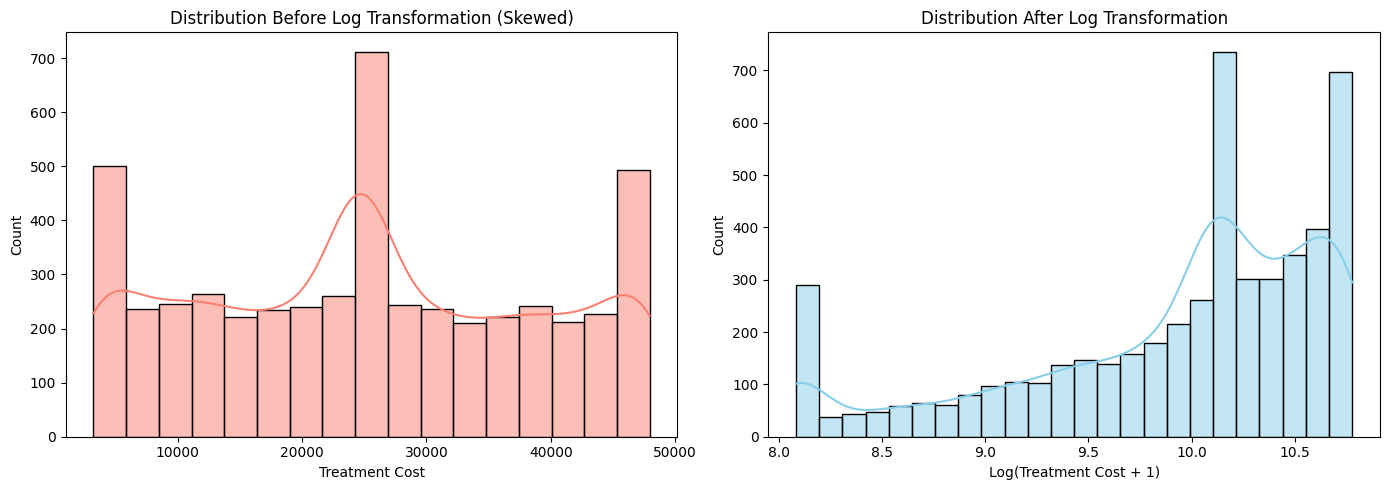

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply log transformation (using log1p to handle any potential 0 values safely)
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

# Compare before vs after distribution using subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution before transformation
sns.histplot(df['Treatment_Cost'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribution Before Log Transformation (Skewed)')
axes[0].set_xlabel('Treatment Cost')

# Distribution after transformation
sns.histplot(df['Log_Treatment_Cost'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution After Log Transformation')
axes[1].set_xlabel('Log(Treatment Cost + 1)')

plt.tight_layout()
plt.show()

In [50]:
('''Q9. Time-Based Missing Handling

Scenario:
Admission dates should follow a logical sequence.

Task:

Sort data by Admission_Date

Apply forward fill or backward fill where appropriate

Justify your choice''')

'Q9. Time-Based Missing Handling\n\nScenario:\nAdmission dates should follow a logical sequence.\n\nTask:\n\nSort data by Admission_Date\n\nApply forward fill or backward fill where appropriate\n\nJustify your choice'

In [51]:
# Convert Admission_Date to datetime objects to ensure correct chronological sequence
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# Sort data by Admission_Date
df = df.sort_values(by='Admission_Date').reset_index(drop=True)

# Apply Forward Fill (ffill)
df = df.ffill()

print("Time-based sorting and forward fill imputation completed successfully.")


Time-based sorting and forward fill imputation completed successfully.


In [52]:
('''Justification: Forward fill (ffill) is the appropriate choice here.
    In chronological health settings , a patient's institutional status, insurance tier, or ward structural parameters stay fixed until an explicit transaction or log changes it. 
    Backward filling would risk leaking future operational context into past empty records.''')

"Justification: Forward fill (ffill) is the appropriate choice here.\n    In chronological health settings , a patient's institutional status, insurance tier, or ward structural parameters stay fixed until an explicit transaction or log changes it. \n    Backward filling would risk leaking future operational context into past empty records."